In [106]:
#!pip install contextily osmnx tqdm geopandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from geopy.distance import geodesic
import osmnx as ox
import unicodedata
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV
import joblib
import contextily as ctx


In [95]:
df = pd.read_csv("listings_cleaned_final.csv")
df.drop(columns=['listing_url', 'name', 'description', 'picture_url', 'host_id',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_listings_count', 'host_has_profile_pic', 'host_identity_verified',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'minimum_nights',
       'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_365',
       'number_of_reviews', 'number_of_reviews_l30d',
       'estimated_occupancy_l365d', 'review_scores_rating',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'instant_bookable', 'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_shared_rooms', 'reviews_per_month',
       'last_review_diff', 'host_since_diff'], inplace=True)
#Columns considered for prediction - neighbourhood, neighbourhood group, latitude, longitude


In [96]:
#Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
id                              0
neighbourhood_cleansed          0
neighbourhood_group_cleansed    0
latitude                        0
longitude                       0
price                           0
dtype: int64


In [97]:
df.head(10)

,id,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,price
0,6624,Santa Croce,Isole,45.43977,12.32736,227.0
1,27116,San Marco,Isole,45.43277,12.33456,187.0
2,44527,Cannaregio,Isole,45.44569,12.32902,391.0
3,47383,San Polo,Isole,45.43921,12.33310,98.0
4,49656,Dorsoduro,Isole,45.43549,12.32612,101.0
5,60304,Cannaregio,Isole,45.44453,12.33300,131.0
6,61714,Giudecca,Isole,45.42708,12.31823,126.0
7,69877,Dorsoduro,Isole,45.43218,12.32572,146.0
8,71735,San Marco,Isole,45.43367,12.33639,127.0
9,423767,Cannaregio,Isole,45.44243,12.32436,140.0


In [98]:
#Price statistics
col = 'price'
print("Statistics for column:", col)
print("Mean:", df[col].mean())
print("Median:", df[col].median())
print("Min:", df[col].min())
print("Max:", df[col].max())

Statistics for column: price
Mean: 202.45974545974545
Median: 139.0
Min: 10.0
Max: 10000.0


In [99]:
df.shape

(6993, 6)

In [100]:
cap = df['price'].quantile(0.95)
print(f"95th percentile price: €{cap:.2f}")

95th percentile price: €437.20


In [101]:
#Filter out outliers
df = df[df['price'] <= 500]

In [102]:
df.shape

(6716, 6)

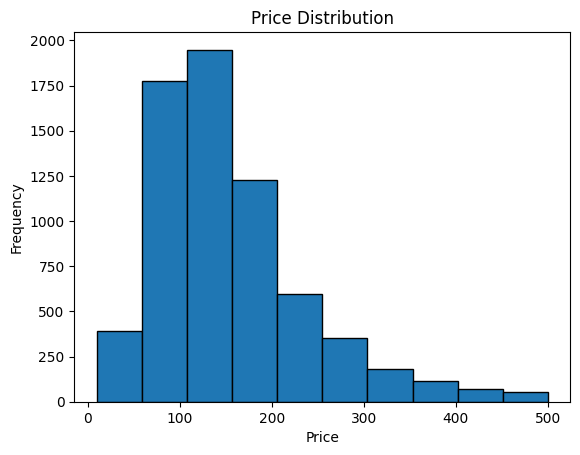

In [103]:
#Histogram of price distribution
plt.hist(df['price'], bins=10, edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Price Distribution')
plt.show()

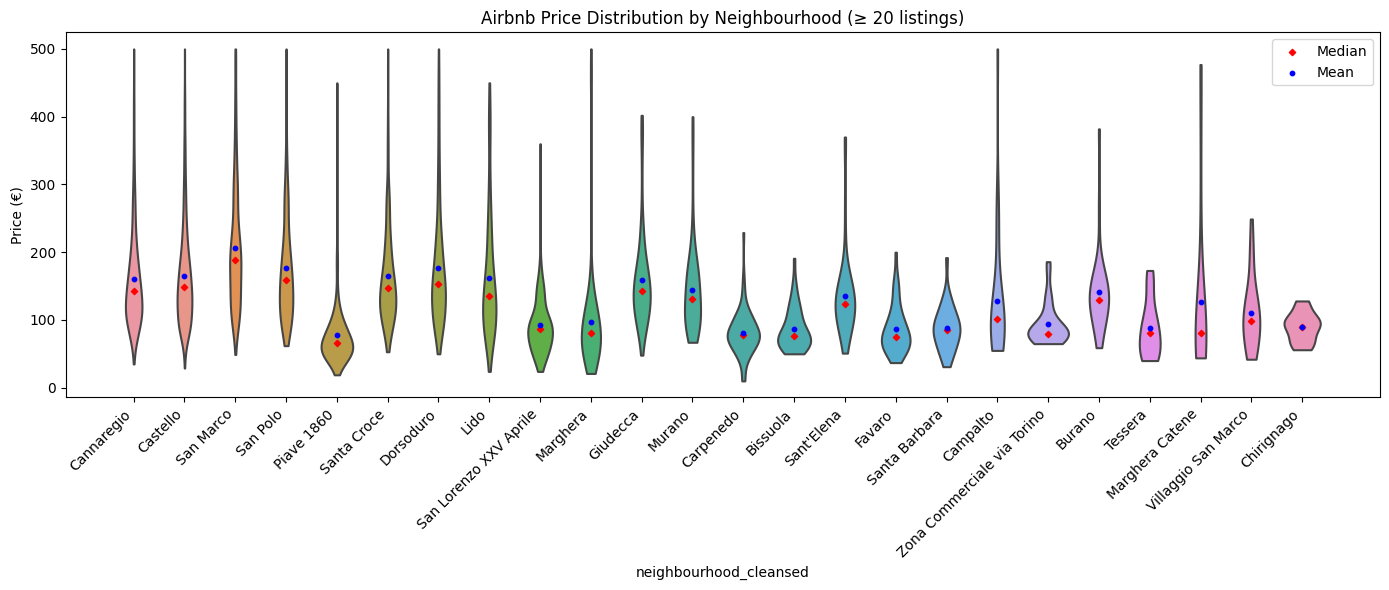

In [104]:
# Filter neighbourhoods with more than 20 listings
neighbourhood_counts = df['neighbourhood_cleansed'].value_counts()
valid_neighbourhoods = neighbourhood_counts[neighbourhood_counts > 20].index
filtered_df = df[df['neighbourhood_cleansed'].isin(valid_neighbourhoods)]

# Sort neighbourhoods for consistent x-tick positioning
neighbourhood_order = filtered_df['neighbourhood_cleansed'].value_counts().loc[valid_neighbourhoods].index

plt.figure(figsize=(14, 6))

# Violin plot
sns.violinplot(
    data=filtered_df,
    x='neighbourhood_cleansed',
    y='price',
    inner=None,
    cut=0,
    order=neighbourhood_order
)

# Calculate group statistics
grouped = filtered_df.groupby('neighbourhood_cleansed')['price']
means = grouped.mean()
medians = grouped.median()

# Get x positions of each category
x_positions = range(len(neighbourhood_order))

# Plot median points (red diamonds)
plt.scatter(
    x=x_positions,
    y=medians[neighbourhood_order],
    color='red',
    marker='D',
    s=10,
    label='Median'
)

# Plot mean points (blue circles)
plt.scatter(
    x=x_positions,
    y=means[neighbourhood_order],
    color='blue',
    marker='o',
    s=10,
    label='Mean'
)

plt.title('Airbnb Price Distribution by Neighbourhood (≥ 20 listings)')
plt.ylabel('Price (€)')
plt.xticks(ticks=x_positions, labels=neighbourhood_order, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


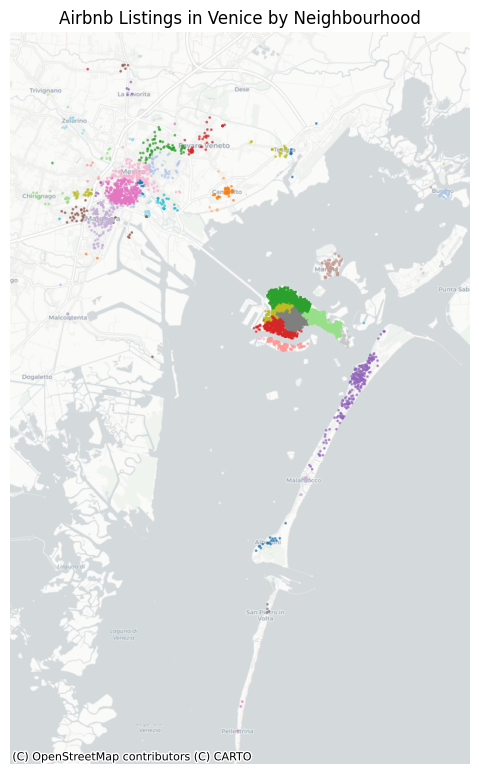

In [ ]:
# converting DataFrame to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"  # WGS84 (lat/lon)
)

# project to Web Mercator for basemap compatibility
gdf = gdf.to_crs(epsg=3857)

# coloured by neighbourhood
fig, ax = plt.subplots(figsize=(12, 8))
gdf.plot(ax=ax, column='neighbourhood_cleansed', cmap='tab20', legend=False, markersize=1, alpha=0.6)

# Adding basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title("Airbnb Listings in Venice by Neighbourhood", fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()


In [111]:
dfOG = df

In [112]:
# Feature Engineering - Distance from City Centre (San Marco Square), Restaurants and eating places in a 1km radius
# Transport Stops and Tourism Spots in a 1km radius and Waterfront Flag

gdf_listings = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")

# fetching Points of Interest (POIs) from OpenStreetMap
print("Fetching POIs from OpenStreetMap...")

tags = {
    'amenity': ['restaurant', 'cafe', 'bus_station', 'ferry_terminal'],
    'tourism': ['museum', 'attraction', 'artwork']
}
pois = ox.features_from_place("Venice, Italy", tags)
pois = pois[pois.geometry.notnull()].to_crs(epsg=3857)
restaurants = pois[pois['amenity'].isin(['restaurant', 'cafe'])]
transport_stops = pois[pois['amenity'].isin(['bus_station', 'ferry_terminal'])]
tourism_spots = pois[pois['tourism'].isin(['museum', 'attraction', 'artwork'])]

# distance to city center
print("Computing distance to city center...")
CITY_CENTER = (45.4340, 12.3386)
gdf_listings['distance_to_center_km'] = gdf_listings.geometry.apply(
    lambda p: geodesic((p.y, p.x), CITY_CENTER).km
)
gdf_listings = gdf_listings.to_crs(epsg=3857)

# POIs within 1 km
print("Counting nearby POIs...")

def count_nearby(gdf_base, gdf_pois, radius):
    return gdf_base.geometry.apply(
        lambda geom: gdf_pois[gdf_pois.geometry.distance(geom) <= radius].shape[0]
    )

gdf_listings['num_restaurants_1km'] = count_nearby(gdf_listings, restaurants, 1000)
gdf_listings['num_transport_stops_1km'] = count_nearby(gdf_listings, transport_stops, 1000)
gdf_listings['num_tourism_spots_1km'] = count_nearby(gdf_listings, tourism_spots, 1000)

# waterfront flag
print("Tagging waterfront listings...")
water = ox.features_from_place('Venice, Italy', tags={'waterway': True})
water = water[water.geometry.notnull()].to_crs(epsg=3857)

gdf_listings['is_waterfront'] = gdf_listings.geometry.apply(
    lambda geom: water.geometry.distance(geom).min() <= 30
)

# "Eating Places" matching
print("Filtering for custom food-related POIs...")

keywords = [
    "osteria", "pizzeria", "paninoteca", "bar", "gastronomia", 
    "panetteria", "trattoria", "ristorante", "pub", "gastropub",
    "panificio", "caffe", "caffè", "gelateria", "steak house"
]

def normalize(text):
    if pd.isna(text): return ""
    return unicodedata.normalize('NFKD', str(text).lower()).encode('ascii', 'ignore').decode('utf-8')

def matches_keywords(row):
    fields = [normalize(row.get('name', '')), normalize(row.get('cuisine', ''))]
    return any(any(k in f for k in keywords) for f in fields)

filtered_restaurants = pois[pois.apply(matches_keywords, axis=1)]

def count_custom_restaurants(gdf_listings, filtered_pois, radius=1000):
    return gdf_listings.geometry.apply(
        lambda geom: filtered_pois[filtered_pois.geometry.distance(geom) <= radius].shape[0]
    )

gdf_listings['num_custom_restaurants_1km'] = count_custom_restaurants(gdf_listings, filtered_restaurants)

# Save results to CSV
print("Saving enriched listings...")
out_df = gdf_listings.drop(columns='geometry')
out_df.to_csv("submission_listings_with_spatial_features_final.csv", index=False)
print("File saved as submission_listings_with_spatial_features_final.csv")


Fetching POIs from OpenStreetMap...
Computing distance to city center...
Counting nearby POIs...
Tagging waterfront listings...
Filtering for custom food-related POIs...
Saving enriched listings...
File saved as submission_listings_with_spatial_features_final.csv


In [113]:
out_df.head(10)

,id,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,price,distance_to_center_km,num_restaurants_1km,num_transport_stops_1km,num_tourism_spots_1km,is_waterfront,num_custom_restaurants_1km
0,6624,Santa Croce,Isole,45.43977,12.32736,227.0,1.088449,287,28,45,False,119
1,27116,San Marco,Isole,45.43277,12.33456,187.0,0.344422,242,23,80,False,124
2,44527,Cannaregio,Isole,45.44569,12.32902,391.0,1.499943,124,13,22,False,59
3,47383,San Polo,Isole,45.43921,12.33310,98.0,0.721451,354,15,67,True,169
4,49656,Dorsoduro,Isole,45.43549,12.32612,101.0,0.990480,237,22,69,False,94
5,60304,Cannaregio,Isole,45.44453,12.33300,131.0,1.249640,178,16,28,False,78
6,61714,Giudecca,Isole,45.42708,12.31823,126.0,1.769873,23,10,8,False,7
7,69877,Dorsoduro,Isole,45.43218,12.32572,146.0,1.027965,162,18,66,True,61
8,71735,San Marco,Isole,45.43367,12.33639,127.0,0.176778,275,26,86,False,142
9,423767,Cannaregio,Isole,45.44243,12.32436,140.0,1.455754,177,22,35,False,80


In [114]:
#K-means clustering on geographical coordinates
geo_coordinates = out_df[['latitude', 'longitude']]
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(geo_coordinates)
out_df['kmeans_cluster_5'] = cluster_labels

c:\Users\swaro_cg46ucd\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [115]:
out_df['kmeans_cluster_5'].value_counts()

kmeans_cluster_5
1    3843
4    1308
2    1110
3     283
0     172
Name: count, dtype: int64

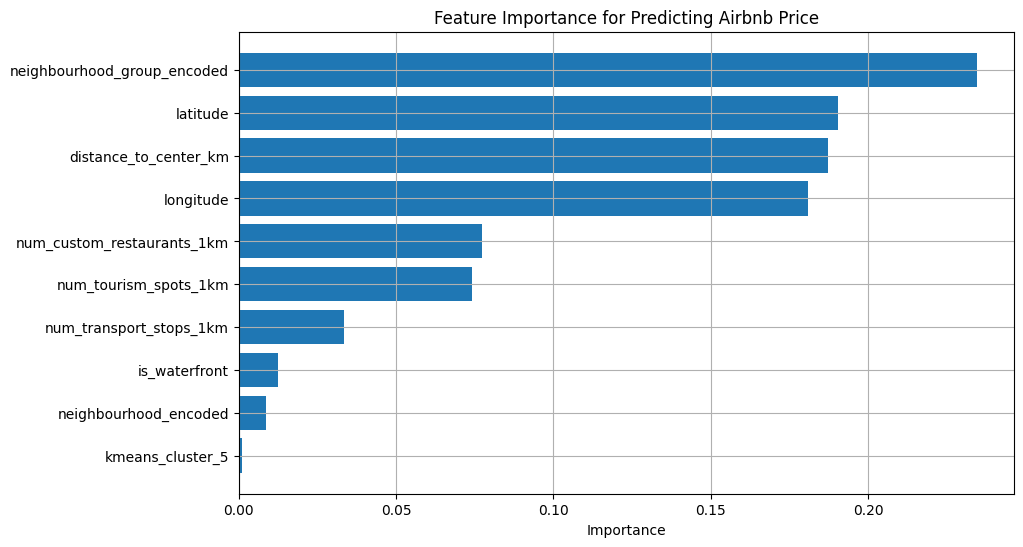

In [126]:
cols_needed = [
    'latitude', 'longitude', 'neighbourhood_cleansed', 'distance_to_center_km', 'neighbourhood_group_cleansed',
    'num_transport_stops_1km', 'num_tourism_spots_1km', 'is_waterfront',
    'num_custom_restaurants_1km', 'kmeans_cluster_5', 'price'
]

# Convert is_waterfront from boolean to integer
out_df['is_waterfront'] = out_df['is_waterfront'].astype(int)

# Encode neighbourhood and neighbourhood group (isole / terraferma)
le1 = LabelEncoder()
out_df['neighbourhood_encoded'] = le1.fit_transform(out_df['neighbourhood_cleansed'])

le2 = LabelEncoder()
out_df['neighbourhood_group_encoded'] = le2.fit_transform(out_df['neighbourhood_group_cleansed'])

# Define feature columns
feature_cols = [
    'latitude', 'longitude', 'neighbourhood_encoded', 'neighbourhood_group_encoded',
    'distance_to_center_km', 'num_transport_stops_1km',
    'num_tourism_spots_1km', 'is_waterfront',
    'num_custom_restaurants_1km', 'kmeans_cluster_5'
]

X = out_df[feature_cols]
y = np.log(out_df['price'])

# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

importances_log_before = model.feature_importances_

# Create DataFrame for importance values
feature_importance_before_logdf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances_log_before
}).sort_values(by='Importance', ascending=False)
before_df = feature_importance_before_logdf.rename(columns={"Importance": "Importance_Before"})


# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_before_logdf['Feature'], feature_importance_before_logdf['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Feature Importance for Predicting Airbnb Price")
plt.grid(True)
plt.show()


In [128]:
joblib.dump(model, "rf_model_log_baseline.pkl")
print("Model saved as rf_model_log_baseline.pkl")

Model saved as rf_model_log_baseline.pkl


In [127]:
y_pred = model.predict(X_test)

r2_before = r2_score(y_test, model.predict(X_test))
mae_before = mean_absolute_error(y_test, model.predict(X_test))
rmse_before = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R² Score: 0.29771817924522637
MAE: 0.3370973442975756
RMSE: 0.4322652458573991


In [118]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='r2',
    n_jobs=1, 
    verbose=2
)

grid_search.fit(X_train, y_train)

log_cv = pd.DataFrame(grid_search.cv_results_)
# Best model found
best_model = grid_search.best_estimator_
joblib.dump(grid_search.best_estimator_, "rf_model_log_gridsearch.pkl")
joblib.dump(grid_search, "gridsearch_full_log.pkl")
# Performance on test set
y_pred = best_model.predict(X_test)

y_test_exp = np.exp(y_test)
y_pred_exp = np.exp(y_pred)

r2_after = r2_score(y_test, y_pred)
mae_after = mean_absolute_error(y_test, y_pred)
rmse_after = np.sqrt(mean_squared_error(y_test, y_pred))
print("Best Parameters:", grid_search.best_params_)
print("R²:", r2_after)
print("MAE:", mae_after)
print("RMSE:", rmse_after)


Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   1.5s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   1.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   1.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   1.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   1.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   2.9s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   2.9s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   2.9s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   2.9s
[CV] END max_depth=N

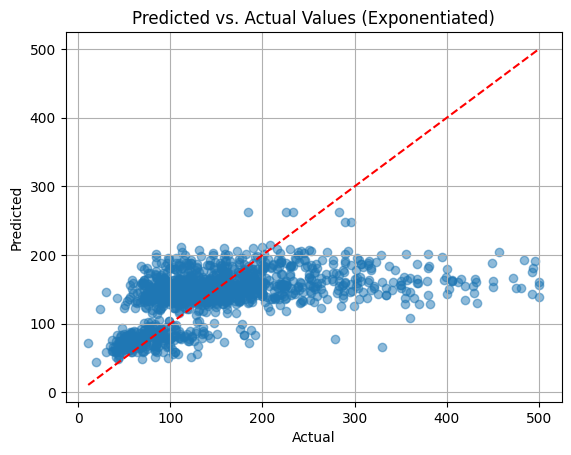

In [119]:
plt.scatter(y_test_exp, y_pred_exp, alpha=0.5)
plt.plot([y_test_exp.min(), y_test_exp.max()], [y_test_exp.min(), y_test_exp.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs. Actual Values (Exponentiated)")
plt.grid(True)
plt.show()


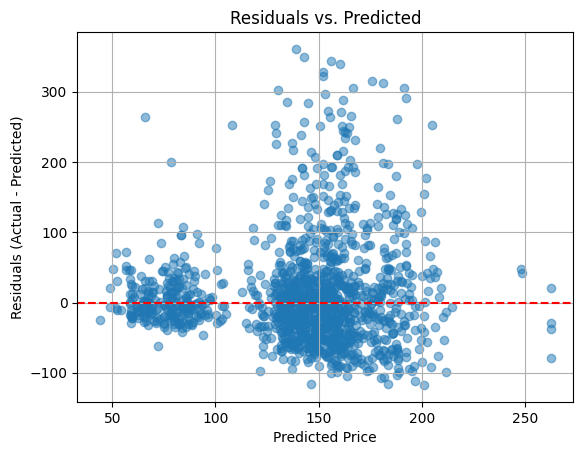

In [120]:
residuals = y_test_exp - y_pred_exp
plt.scatter(y_pred_exp, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs. Predicted")
plt.grid(True)
plt.show()


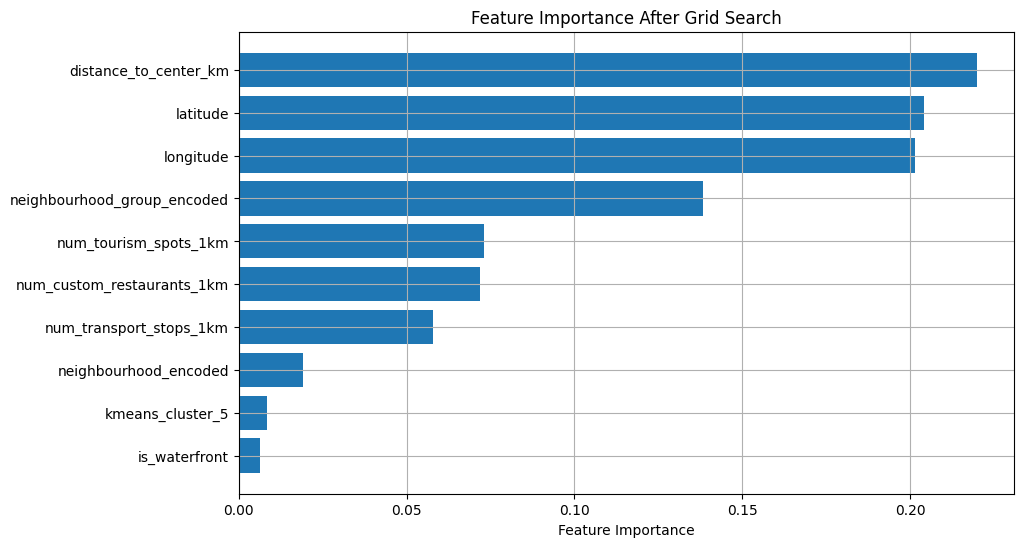

In [129]:
# --- Feature importance for best model ---
importances_after = best_model.feature_importances_
feature_importance_after_logdf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances_after
}).sort_values(by='Importance', ascending=False)
after_df = feature_importance_after_logdf.rename(columns={"Importance": "Importance_After"})


plt.figure(figsize=(10, 6))
plt.barh(feature_importance_after_logdf['Feature'], feature_importance_after_logdf['Importance'])
plt.xlabel("Feature Importance")
plt.title("Feature Importance After Grid Search")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()


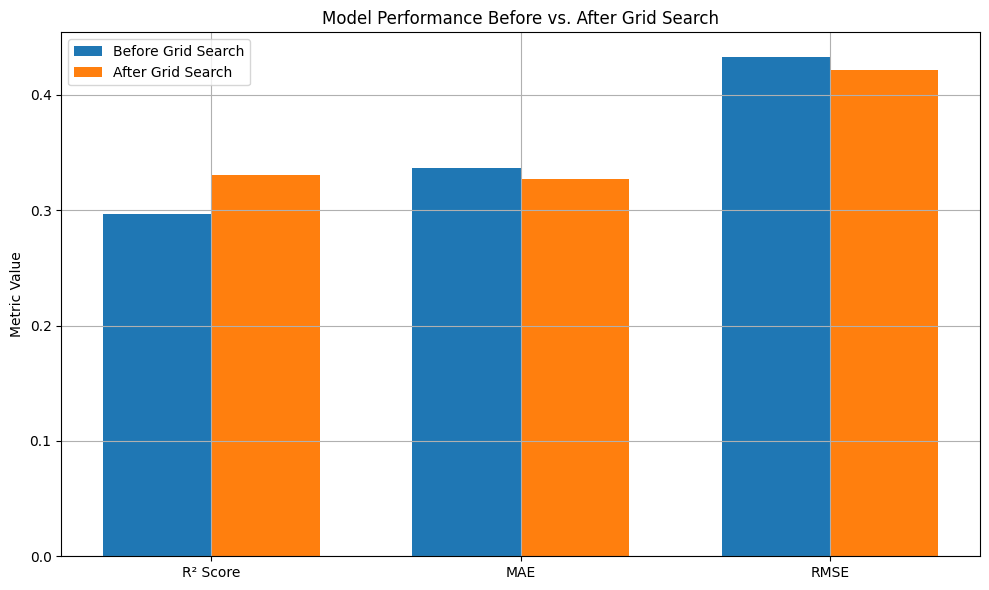

In [122]:
metrics = ['R² Score', 'MAE', 'RMSE']
before = [r2_before, mae_before, rmse_before]
after = [r2_after, mae_after, rmse_after]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, before, width, label='Before Grid Search')
plt.bar(x + width/2, after, width, label='After Grid Search')

plt.xticks(x, metrics)
plt.ylabel("Metric Value")
plt.title("Model Performance Before vs. After Grid Search")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

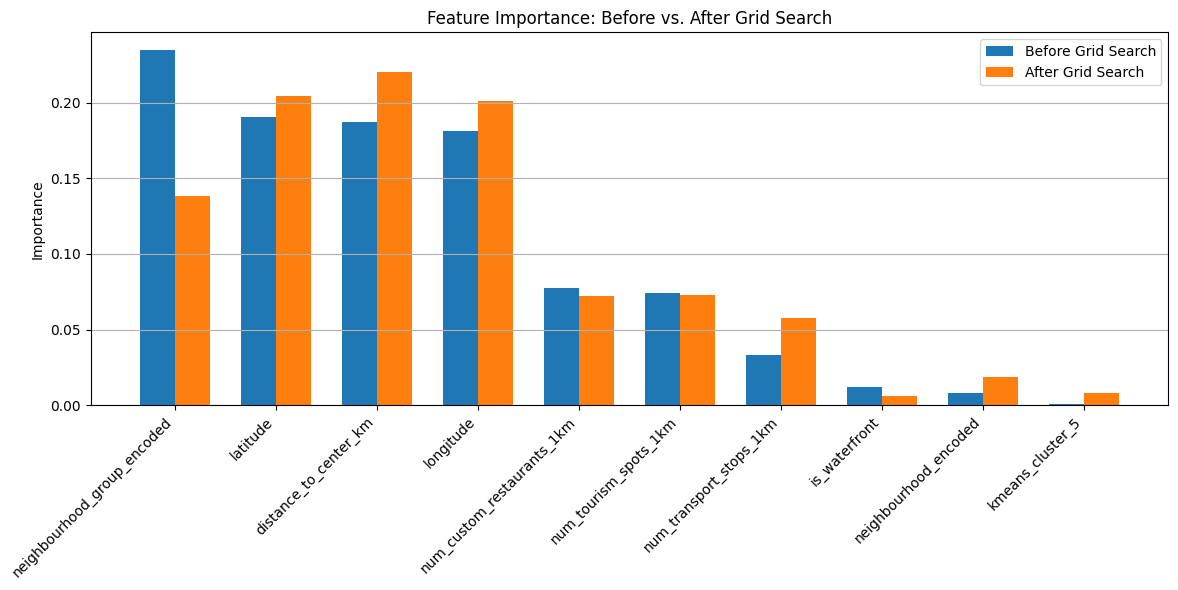

In [130]:
#merged_imp = pd.merge(feature_importance_before_logdf, feature_importance_after_logdf, on='Feature', suffixes=('_Before', '_After')).sort_values(by='Importance_Before', ascending=False)

merged_imp = pd.merge(before_df, after_df, on='Feature').sort_values(by='Importance_Before', ascending=False)
# Plotting
x = np.arange(len(merged_imp))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, merged_imp['Importance_Before'], width, label='Before Grid Search')
plt.bar(x + width/2, merged_imp['Importance_After'], width, label='After Grid Search')

plt.xticks(x, merged_imp['Feature'], rotation=45, ha='right')
plt.ylabel("Importance")
plt.title("Feature Importance: Before vs. After Grid Search")
plt.legend()
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()

In [131]:
# Define raw target
y_raw = out_df['price']

# Train-test split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y_raw, test_size=0.2, random_state=42
)

# Train base model
rf_raw = RandomForestRegressor(n_estimators=100, random_state=42)
rf_raw.fit(X_train_raw, y_train_raw)

# predictions
y_pred_raw = rf_raw.predict(X_test_raw)

# Metrics BEFORE tuning
r2_raw_before = r2_score(y_test_raw, y_pred_raw)
mae_raw_before = mean_absolute_error(y_test_raw, y_pred_raw)
rmse_raw_before = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw))

joblib.dump(rf_raw, "rf_model_raw_baseline.pkl")
print("Model saved as rf_model_raw_baseline.pkl")

print("Raw Price Model BEFORE GridSearch")
print(f"R²: {r2_raw_before:.4f}")
print(f"MAE: {mae_raw_before:.2f}")
print(f"RMSE: {rmse_raw_before:.2f}")

# Feature importance BEFORE
feat_imp_raw_before = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_raw.feature_importances_
}).sort_values(by='Importance', ascending=False)
raw_before_df = feat_imp_raw_before.rename(columns={"Importance": "Importance_Before"})

Model saved as rf_model_raw_baseline.pkl
Raw Price Model BEFORE GridSearch
R²: 0.1654
MAE: 54.97
RMSE: 76.51


In [143]:
# Grid Search on raw price model
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20,30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search_raw = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=1,
    verbose=2
)

grid_search_raw.fit(X_train_raw, y_train_raw)
raw_cv = pd.DataFrame(grid_search_raw.cv_results_)

# Best tuned model
best_rf_raw = grid_search_raw.best_estimator_

joblib.dump(grid_search_raw.best_estimator_, "rf_model_raw_gridsearch.pkl")
joblib.dump(grid_search_raw, "gridsearch_full_raw.pkl")

# Predictions
y_pred_raw_after = best_rf_raw.predict(X_test_raw)

# Metrics AFTER tuning
r2_raw_after = r2_score(y_test_raw, y_pred_raw_after)
mae_raw_after = mean_absolute_error(y_test_raw, y_pred_raw_after)
rmse_raw_after = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw_after))

print("\n=== Raw Price Model AFTER GridSearch ===")
print(f"Best Params: {grid_search_raw.best_params_}")
print(f"R²: {r2_raw_after:.4f}")
print(f"MAE: {mae_raw_after:.2f}")
print(f"RMSE: {rmse_raw_after:.2f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   1.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   1.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   1.5s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   1.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   1.5s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   4.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   5.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   5.3s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   5.2s
[CV] END max_depth=N

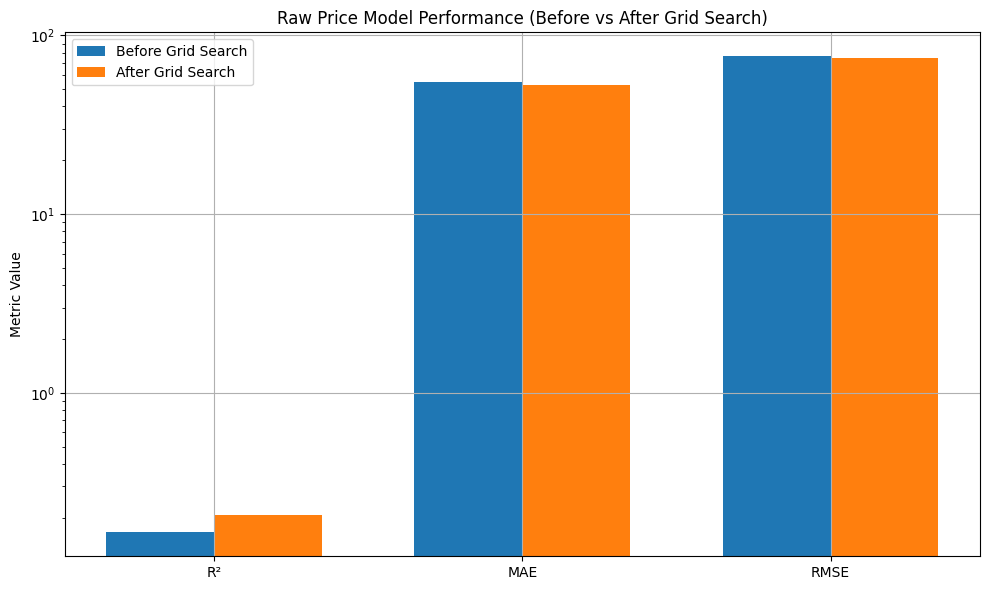

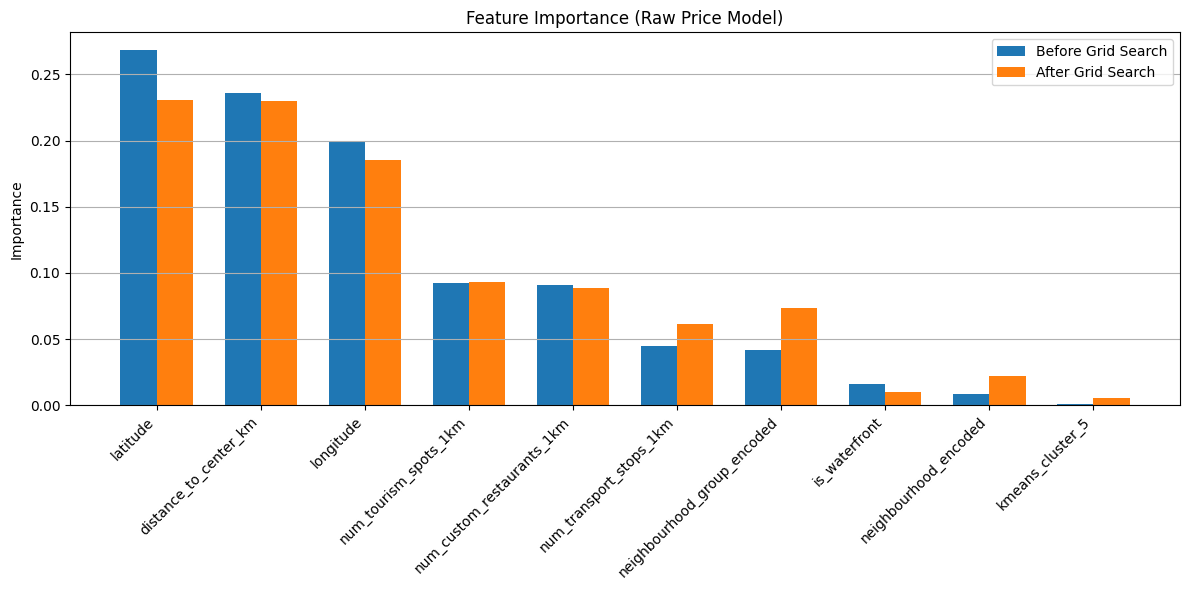

In [ ]:
#Convert Log Model Predictions to Original Price Scale
y_test_exp = np.exp(y_test)
y_pred_exp_before = np.exp(model.predict(X_test))        # Baseline log model
y_pred_exp_after  = np.exp(best_model.predict(X_test))   # Grid-searched log model

#Recalculate Log Model Metrics in Euros Scale
r2_log_exp_before = r2_score(y_test_exp, y_pred_exp_before)
mae_log_exp_before = mean_absolute_error(y_test_exp, y_pred_exp_before)
rmse_log_exp_before = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp_before))

r2_log_exp_after = r2_score(y_test_exp, y_pred_exp_after)
mae_log_exp_after = mean_absolute_error(y_test_exp, y_pred_exp_after)
rmse_log_exp_after = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp_after))

# Feature importance AFTER
feat_imp_raw_after = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_rf_raw.feature_importances_
}).sort_values(by='Importance', ascending=False)
raw_after_df = feat_imp_raw_after.rename(columns={"Importance": "Importance_After"})

# Metric Comparison Plot
metrics = ['R²', 'MAE', 'RMSE']
before_raw = [r2_raw_before, mae_raw_before, rmse_raw_before]
after_raw = [r2_raw_after, mae_raw_after, rmse_raw_after]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, before_raw, width, label='Before Grid Search')
plt.bar(x + width/2, after_raw, width, label='After Grid Search')
plt.xticks(x, metrics)
plt.yscale('log')
plt.ylabel("Metric Value")
plt.title("Raw Price Model Performance (Before vs After Grid Search)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Feature Importance Comparison Plot
merged_feat_imp_raw = pd.merge(raw_before_df, raw_after_df, on='Feature').sort_values(by='Importance_Before', ascending=False)
x = np.arange(len(merged_feat_imp_raw))
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, merged_feat_imp_raw['Importance_Before'], width, label='Before Grid Search')
plt.bar(x + width/2, merged_feat_imp_raw['Importance_After'], width, label='After Grid Search')
plt.xticks(x, merged_feat_imp_raw['Feature'], rotation=45, ha='right')
plt.ylabel("Importance")
plt.title("Feature Importance (Raw Price Model)")
plt.legend()
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()

In [ ]:
# Merge all on 'Feature'
all_feat_imp = feature_importance_before_logdf.rename(columns={'Importance': 'Log_Before'})
all_feat_imp = all_feat_imp.merge(
    feature_importance_after_logdf.rename(columns={'Importance': 'Log_After'}), on='Feature'
)
all_feat_imp = all_feat_imp.merge(
    feat_imp_raw_before.rename(columns={'Importance': 'Raw_Before'}), on='Feature'
)
all_feat_imp = all_feat_imp.merge(
    feat_imp_raw_after.rename(columns={'Importance': 'Raw_After'}), on='Feature'
)

# Sort by mean importance across all models
all_feat_imp['Mean_Importance'] = all_feat_imp[['Log_Before', 'Log_After', 'Raw_Before', 'Raw_After']].mean(axis=1)
all_feat_imp = all_feat_imp.sort_values(by='Mean_Importance', ascending=False)


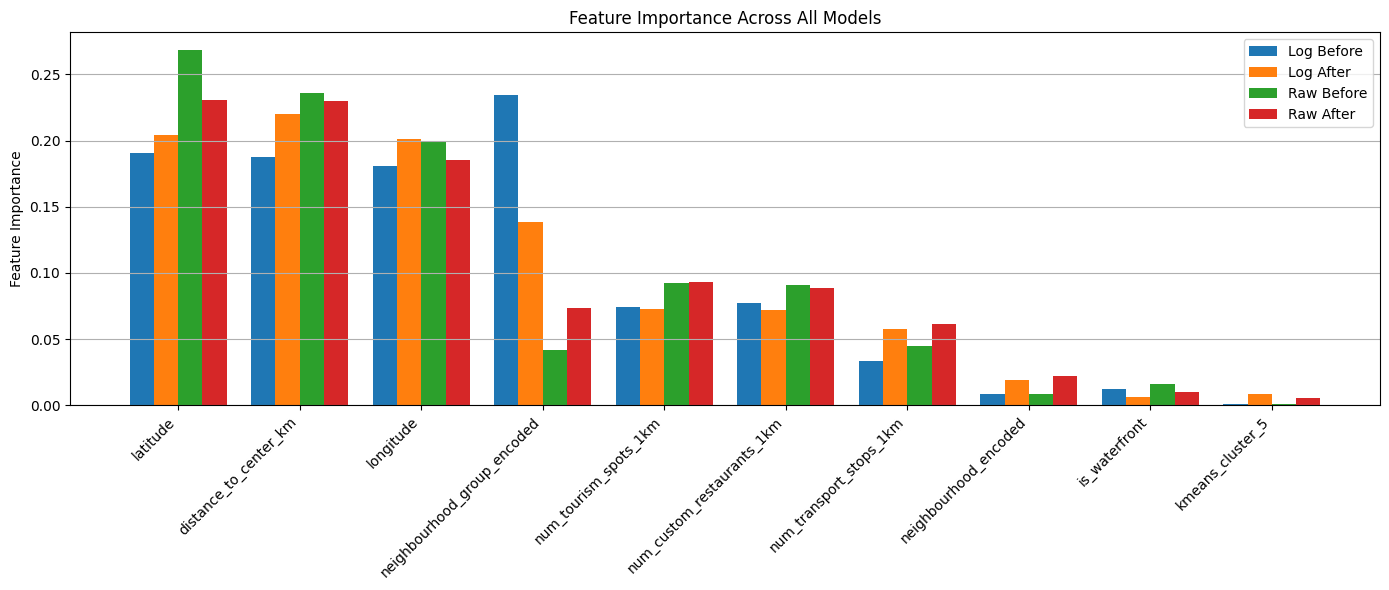

In [146]:
x = np.arange(len(all_feat_imp))
width = 0.2

plt.figure(figsize=(14, 6))
plt.bar(x - 1.5*width, all_feat_imp['Log_Before'], width, label='Log Before')
plt.bar(x - 0.5*width, all_feat_imp['Log_After'], width, label='Log After')
plt.bar(x + 0.5*width, all_feat_imp['Raw_Before'], width, label='Raw Before')
plt.bar(x + 1.5*width, all_feat_imp['Raw_After'], width, label='Raw After')

plt.xticks(x, all_feat_imp['Feature'], rotation=45, ha='right')
plt.ylabel("Feature Importance")
plt.title("Feature Importance Across All Models")
plt.legend()
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()


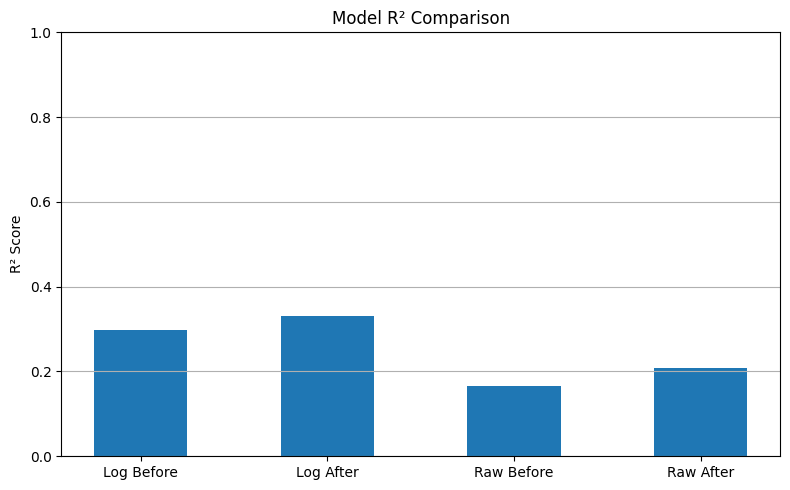

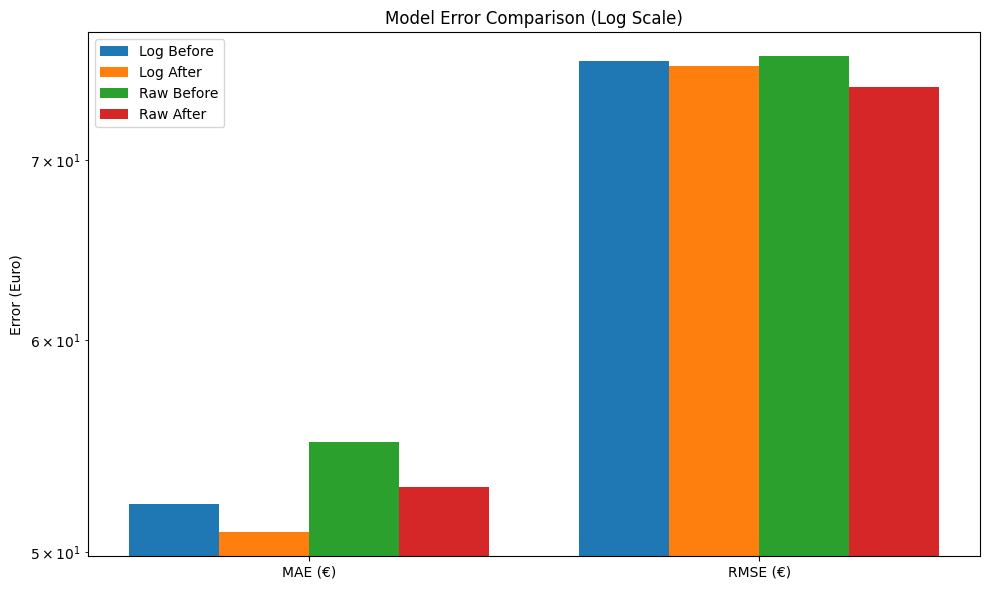

In [ ]:
# Rebuild Metric Lists for Plotting (All in € Scale)
metrics_log_before_eur = [r2_before, mae_log_exp_before, rmse_log_exp_before]
metrics_log_after_eur  = [r2_after,  mae_log_exp_after,  rmse_log_exp_after]

metrics_raw_before = [r2_raw_before, mae_raw_before, rmse_raw_before]
metrics_raw_after  = [r2_raw_after,  mae_raw_after,  rmse_raw_after]

# R2 Plot
x = np.arange(1)
width = 0.2

r2_vals = [
    metrics_log_before_eur[0], metrics_log_after_eur[0],
    metrics_raw_before[0], metrics_raw_after[0]
]

labels = ['Log Before', 'Log After', 'Raw Before', 'Raw After']

plt.figure(figsize=(8, 5))
plt.bar(np.arange(len(r2_vals)), r2_vals, width=0.5)
plt.xticks(np.arange(len(r2_vals)), labels)
plt.ylabel("R² Score")
plt.title("Model R² Comparison")
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# MAE & RMSE Plot (Log Scale)
x = np.arange(2)  # MAE and RMSE
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - 1.5*width, metrics_log_before_eur[1:], width, label='Log Before')
plt.bar(x - 0.5*width, metrics_log_after_eur[1:], width, label='Log After')
plt.bar(x + 0.5*width, metrics_raw_before[1:], width, label='Raw Before')
plt.bar(x + 1.5*width, metrics_raw_after[1:], width, label='Raw After')

plt.xticks(x, ['MAE (€)', 'RMSE (€)'])
plt.ylabel("Error (Euro)")
plt.yscale('log')  # Log scale for better visual separation
plt.title("Model Error Comparison (Log Scale)")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

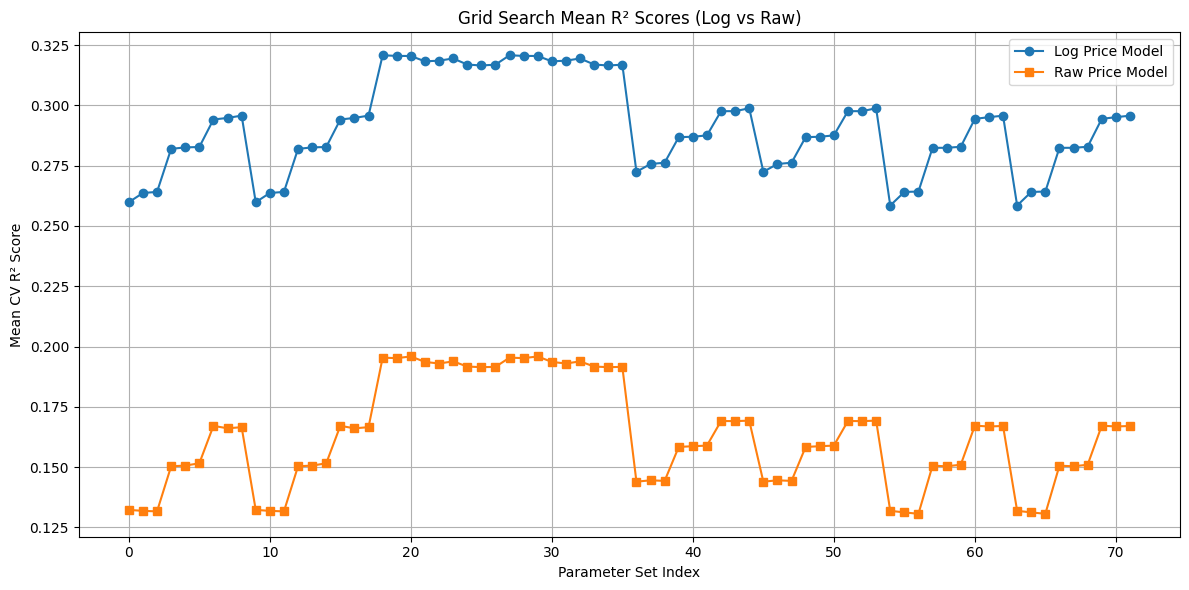

In [148]:
plt.figure(figsize=(12, 6))
plt.plot(log_cv['mean_test_score'], label='Log Price Model', marker='o')
plt.plot(raw_cv['mean_test_score'], label='Raw Price Model', marker='s')
plt.title("Grid Search Mean R² Scores (Log vs Raw)")
plt.xlabel("Parameter Set Index")
plt.ylabel("Mean CV R² Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()